<a href="https://colab.research.google.com/github/SIVASURYAPK/Data-Cleaning-Visualization-Project/blob/main/Week1_Data_Cleaning_and_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np

# 1. Load the dataset
df = pd.read_csv('/content/movies.csv')
print(f"Original shape: {df.shape}")

# ==========================================
# THIRANEX TASK: DATA PREPROCESSING
# ==========================================

# --- 1. HANDLE DUPLICATES ---
df.drop_duplicates(inplace=True)

# --- 2. CLEAN UP MESSY TEXT DATA ---
# Remove the weird '\n' characters from genres and stars
if 'GENRE' in df.columns:
    df['GENRE'] = df['GENRE'].str.replace('\n', '', regex=False).str.strip()
if 'YEAR' in df.columns:
    # Clean brackets and weird characters from the Year column
    df['YEAR'] = df['YEAR'].str.replace(r'[^0-9–]', '', regex=True)

# --- 3. HANDLE MISSING VALUES ---
# Drop the 'Gross' column because it's missing 95% of its data
df.drop(columns=['Gross'], inplace=True, errors='ignore')

# Impute (fill) missing Ratings with the Median rating
median_rating = df['RATING'].median()
df['RATING'].fillna(median_rating, inplace=True)

# Impute missing RunTime with the Median RunTime
median_runtime = df['RunTime'].median()
df['RunTime'].fillna(median_runtime, inplace=True)

# For missing Genres or Years, fill with a placeholder string
df['GENRE'].fillna('Unknown', inplace=True)
df['YEAR'].fillna('Unknown', inplace=True)

# --- 4. HANDLE OUTLIERS (RunTime) ---
# A 853-minute runtime skews our charts. Let's cap movies at a maximum of 3.5 hours (210 mins)
df.loc[df['RunTime'] > 210, 'RunTime'] = 210

print(f"\nCleaned shape: {df.shape}")
print(f"Missing ratings now: {df['RATING'].isnull().sum()}")

Original shape: (9999, 9)

Cleaned shape: (9568, 8)
Missing ratings now: 0


/tmp/ipykernel_9155/3228252712.py:29: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['RATING'].fillna(median_rating, inplace=True)
/tmp/ipykernel_9155/3228252712.py:33: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

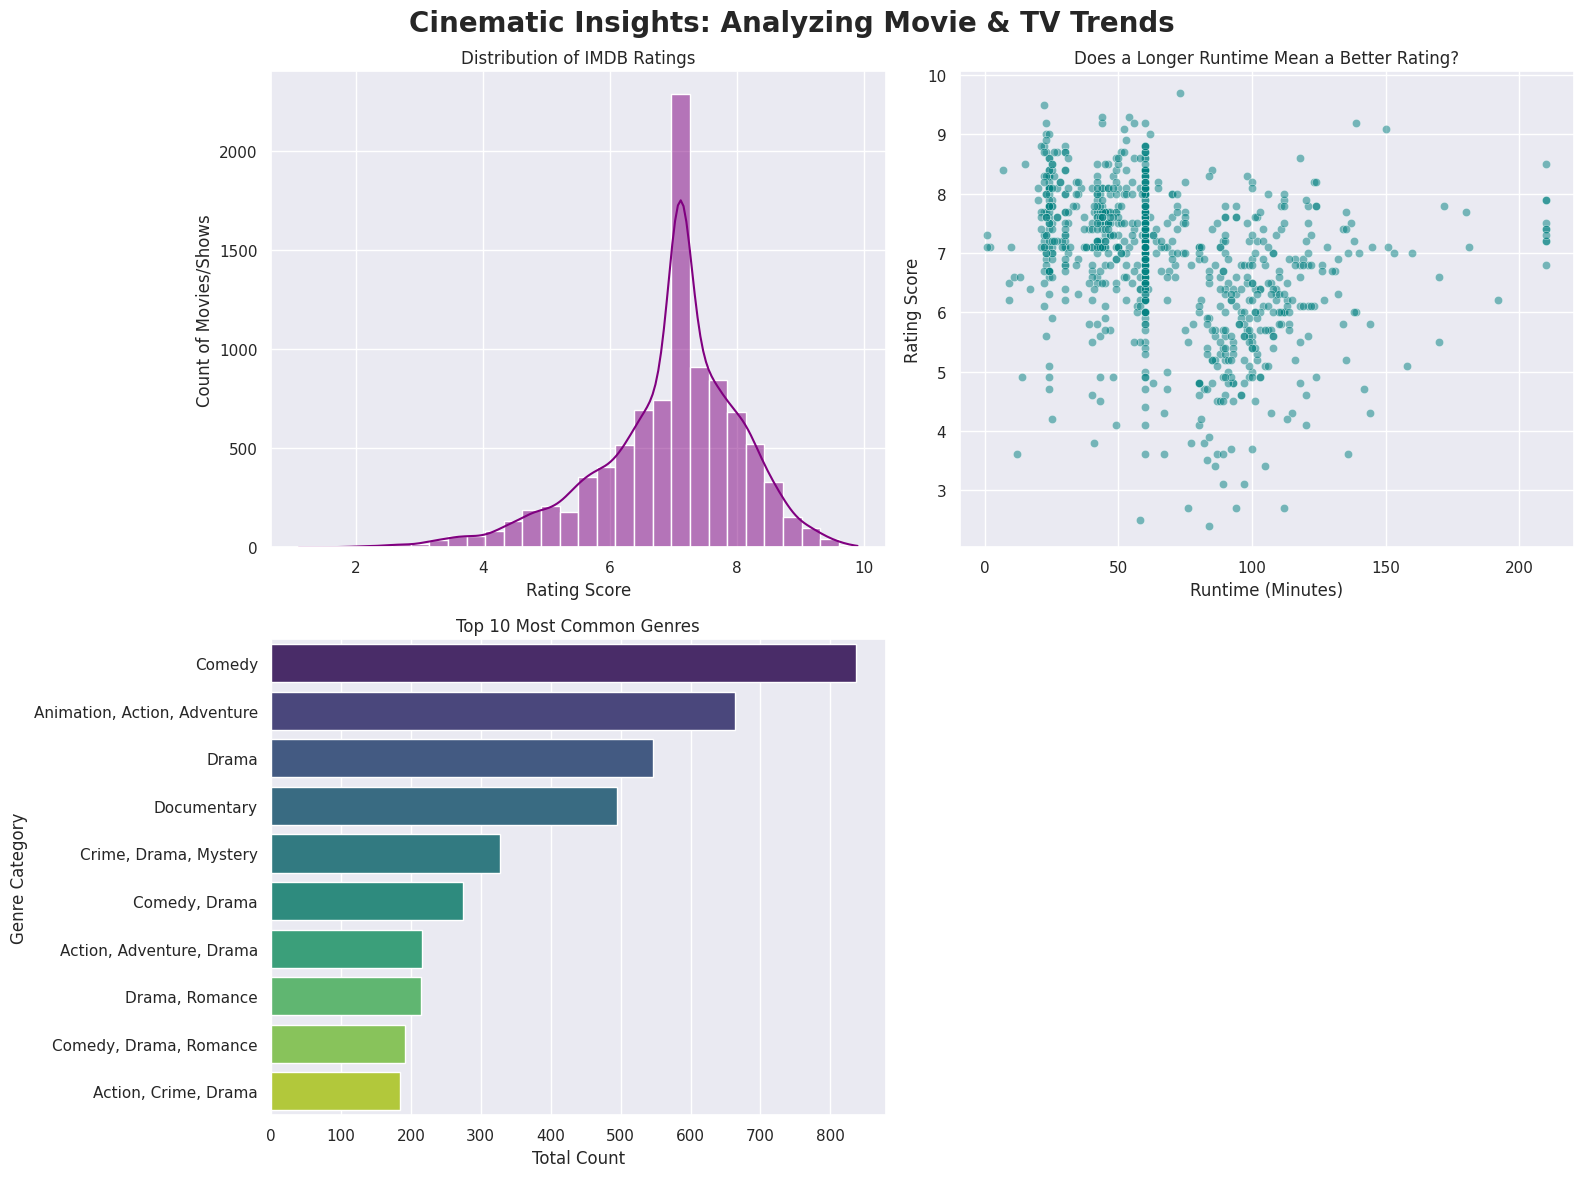

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a professional visual style
sns.set_theme(style="darkgrid")

# 1. Create the dashboard canvas (2 rows, 2 columns)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Cinematic Insights: Analyzing Movie & TV Trends', fontsize=20, fontweight='bold')

# --- CHART 1: The Rating Curve (Top Left) ---
# Shows the distribution of ratings. The KDE line shows the "bell curve".
sns.histplot(data=df, x='RATING', bins=30, kde=True, ax=axes[0, 0], color='purple')
axes[0, 0].set_title('Distribution of IMDB Ratings')
axes[0, 0].set_xlabel('Rating Score')
axes[0, 0].set_ylabel('Count of Movies/Shows')

# --- CHART 2: Length vs. Quality (Top Right) ---
# We sample 1000 random points so the scatter plot isn't a solid, unreadable block of color
sns.scatterplot(data=df.sample(1000, random_state=42), x='RunTime', y='RATING', alpha=0.5, ax=axes[0, 1], color='teal')
axes[0, 1].set_title('Does a Longer Runtime Mean a Better Rating?')
axes[0, 1].set_xlabel('Runtime (Minutes)')
axes[0, 1].set_ylabel('Rating Score')

# --- CHART 3: Top Genres (Bottom Left) ---
# Grabs the top 10 most common genres and plots them horizontally
top_genres = df['GENRE'].value_counts().head(10)
sns.barplot(x=top_genres.values, y=top_genres.index, ax=axes[1, 0], hue=top_genres.index, palette='viridis', legend=False)
axes[1, 0].set_title('Top 10 Most Common Genres')
axes[1, 0].set_xlabel('Total Count')
axes[1, 0].set_ylabel('Genre Category')

# --- Clean up the layout ---
# We hide the bottom-right empty quadrant for a cleaner look
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()